<a href="https://colab.research.google.com/github/kccasey1985/Case-Study-Bank-Marketting-/blob/main/Google_Colab_2_Prediction_Engine_future_risk_integrated_04142026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grad Project

## Operating Room Scheduling - Risk Indicator Prediction


Schedule features

→ predict workload intensity

→ track cumulative exposure

→ estimate burnout risk

Operational features:

weekday

month

holiday

distance_band

shift

Workload features:

crna_load

res_load



Rolling workload indicators:

crna_ma_5

res_ma_5



Faculty characteristics:

provider_age

years_practicing



Time tracking:

week_index

# Imports

In [88]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [89]:
df = pd.read_csv("/content/closed_loop_shift_level_output.csv")

print("Shape:", df.shape)
print("\nFirst 10 columns:")
print(df.columns[:10].tolist())

print("\nTarget preview:")
print(df[["risk_index", "risk_band"]].head())

Shape: (2924, 293)

First 10 columns:
['faculty', 'date', 'shift_x', 'weekday', 'month', 'week', 'holiday', 'crna_crna62', 'crna_crna29', 'crna_crna31']

Target preview:
   risk_index risk_band
0    0.771466       Low
1    1.516126       Low
2    1.348912       Low
3    4.407857      High
4    1.807818       Low


In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Basic Cleaning

In [91]:
# Copy so we do not overwrite the original

data = df.copy()

# Convert date to datetime
data["date"] = pd.to_datetime(data["date"], errors="coerce")

# Optional date features
data["year"] = data["date"].dt.year
data["day"] = data["date"].dt.day

# Remove columns that should NOT be used as predictors
# We avoid direct leakage from outputs that are too close to the target
drop_cols = [
    "risk_index",      # target
    "risk_band",       # target-like label
    "date",            # raw date, replaced with year/month/day if needed
    "faculty_id"       # duplicate of faculty in your file
]

# Keep only columns that exist
drop_cols = [c for c in drop_cols if c in data.columns]

X = data.drop(columns=drop_cols)
y = data["risk_index"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)


X shape: (2924, 291)
y shape: (2924,)


# Identify Feature Types

In [92]:
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("\nNumber of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))


Number of numeric columns: 49
Number of categorical columns: 242


# Preprocessing

In [93]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
])

# Train/Test Split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2339, 291)
Test shape: (585, 291)


# Define Models

In [95]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42)
}

# Train and Evaluate

In [96]:
results = []

fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by="RMSE")
print("\nModel Performance:")
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/loc


Model Performance:
               Model       MAE      RMSE        R2
0  Linear Regression  0.000007  0.000170  1.000000
1   Ridge Regression  0.002020  0.002909  0.999995
2      Random Forest  0.025816  0.057720  0.998057
3  Gradient Boosting  0.043996  0.064778  0.997552


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


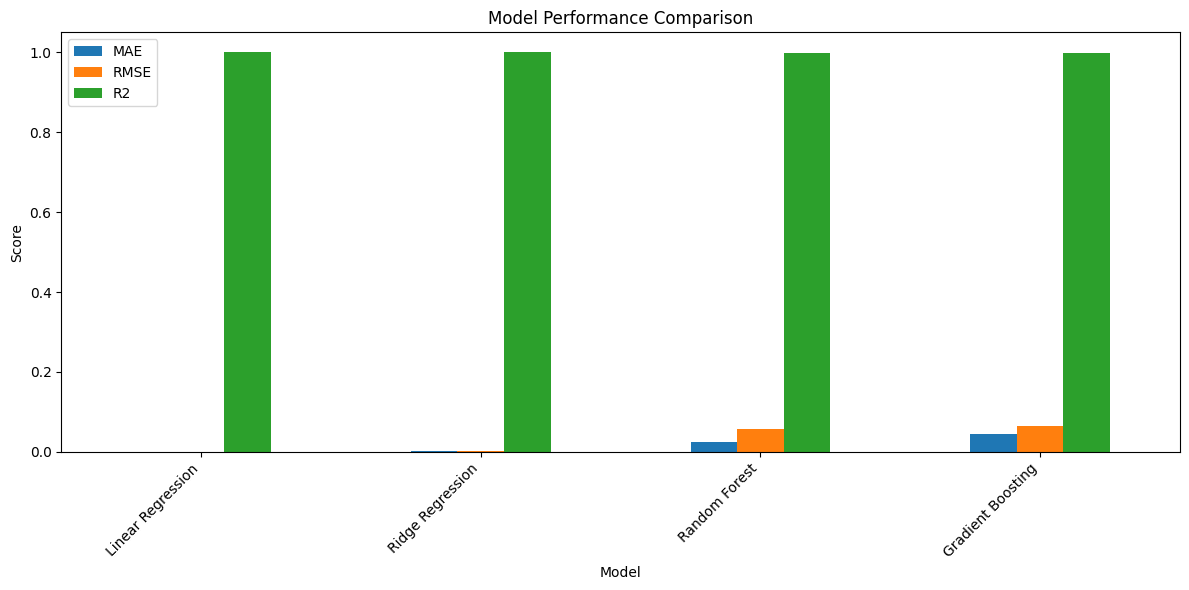

In [97]:
results_df.set_index("Model").plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [98]:
import joblib

best_model_name = results_df.iloc[0]["Model"]
best_model_pipeline = fitted_pipelines[best_model_name]

# Define a filename for the saved model
model_filename = "best_risk_prediction_model.joblib"

# Save the pipeline
joblib.dump(best_model_pipeline, model_filename)

print(f"Best model ('{best_model_name}') pipeline saved as {model_filename}")

Best model ('Linear Regression') pipeline saved as best_risk_prediction_model.joblib


In [99]:
import joblib

# Load the saved pipeline
loaded_pipeline = joblib.load(model_filename)

# Make predictions on X_test
predictions = loaded_pipeline.predict(X_test)

print("First 10 predictions on X_test:")
print(predictions[:10])

First 10 predictions on X_test:
[2.70162044 1.65234821 3.40534811 1.9162525  5.12703253 1.3236858
 2.24961917 3.52728799 5.01876629 3.19091529]


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


First 10 Actual vs. Predicted values:
     Actual  Predicted
0  2.701620   2.701620
1  1.652348   1.652348
2  3.405348   3.405348
3  1.916252   1.916252
4  5.127033   5.127033
5  1.323686   1.323686
6  2.249619   2.249619
7  3.527288   3.527288
8  5.018766   5.018766
9  3.190915   3.190915


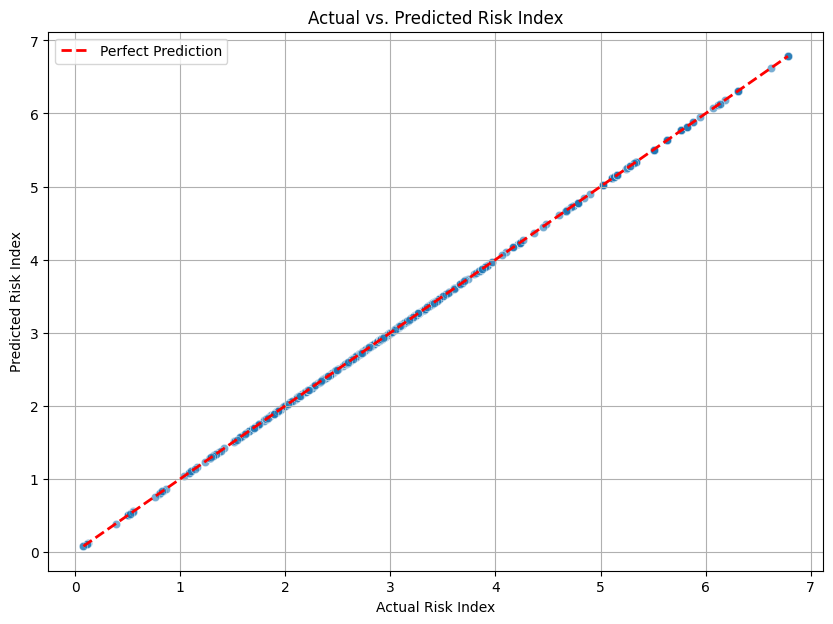

In [100]:
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
}).reset_index(drop=True)

print("First 10 Actual vs. Predicted values:")
print(comparison_df.head(10))

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual', y='Predicted', data=comparison_df, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Risk Index')
plt.xlabel('Actual Risk Index')
plt.ylabel('Predicted Risk Index')
plt.legend()
plt.grid(True)
plt.show()

In [101]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Print the results
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R-squared (R2): {r2:.6f}")

Mean Absolute Error (MAE): 0.000007
R-squared (R2): 1.000000


In [102]:
print("Metrics for the loaded best model (Linear Regression):")
print(f"MAE: {mae:.6f} | R2: {r2:.6f}\n")

print("Comparison against all evaluated models (from training loop):")
display(results_df[['Model', 'MAE', 'R2']].sort_values(by='MAE'))

Metrics for the loaded best model (Linear Regression):
MAE: 0.000007 | R2: 1.000000

Comparison against all evaluated models (from training loop):


,Model,MAE,R2
0,Linear Regression,0.000007,1.000000
1,Ridge Regression,0.002020,0.999995
2,Random Forest,0.025816,0.998057
3,Gradient Boosting,0.043996,0.997552


In [103]:
print(f"Total features used: {len(X.columns)}")
print("\nList of features:")
print(list(X.columns))

Total features used: 291

List of features:
['faculty', 'shift_x', 'weekday', 'month', 'week', 'holiday', 'crna_crna62', 'crna_crna29', 'crna_crna31', 'crna_crnaj', 'crna_crna60', 'crna_crnaq', 'crna_crna77', 'crna_crnat', 'crna_crna48', 'crna_crnaa', 'crna_crnab', 'crna_crnav', 'crna_crnas', 'crna_crna72', 'crna_crna40', 'crna_crnal', 'crna_crna28', 'crna_crna33', 'crna_crna63', 'crna_crna27', 'crna_crna51', 'crna_crnah', 'crna_crna46', 'crna_crna75', 'crna_crna34', 'crna_crna54', 'crna_crna50', 'crna_crna69', 'crna_crna68', 'crna_crna32', 'crna_crnag', 'crna_crna37', 'crna_crna61', 'crna_crna55', 'crna_crna58', 'crna_crnaz', 'crna_crna57', 'crna_crnac', 'crna_crna56', 'crna_crnad', 'crna_crna64', 'crna_crnao', 'crna_crna67', 'crna_crna53', 'crna_crna66', 'crna_crna76', 'crna_crna70', 'crna_crna52', 'crna_crnap', 'crna_crna65', 'crna_crna35', 'crna_crna80', 'crna_crna41', 'crna_crna39', 'crna_crnae', 'crna_crna42', 'crna_crna44', 'crna_crna45', 'crna_crnar', 'crna_crna43', 'crna_crnan

In [104]:
import pandas as pd

# Select only numeric columns from X
numeric_X = X.select_dtypes(include=['number'])

# Calculate the absolute correlation with the target variable 'y'
correlations = numeric_X.corrwith(y).abs().sort_values(ascending=False)

print("Top 15 numeric features most highly correlated with 'risk_index':")
print(correlations.head(15))

# You can also flag ones above a certain threshold, e.g., 0.95
suspects = correlations[correlations > 0.95]
print("\nHighly suspicious features (correlation > 0.95):")
print(suspects)

Top 15 numeric features most highly correlated with 'risk_index':
intensity_raw                        0.905595
pred_utilization                     0.798844
distance_miles                       0.787513
distance_from_san_antonio_miles      0.787474
overtime_prob                        0.646502
priority                             0.595138
total_assist_load                    0.484939
room_delta                           0.437036
imbalance_score                      0.430849
room_count                           0.428939
room_ratio                           0.413622
years_since_med_school_graduation    0.393598
years_since_med_school               0.393598
med_school_grad_year                 0.393598
birth_year                           0.368110
dtype: float64

Highly suspicious features (correlation > 0.95):
Series([], dtype: float64)


In [105]:
# Drop 'intensity_raw' to prevent data leakage
if 'intensity_raw' in X.columns:
    X = X.drop(columns=['intensity_raw'])
    print("'intensity_raw' successfully removed from features.")

# Re-identify column types
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

# Re-define preprocessor with updated columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train and Evaluate Models
results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by="RMSE")
print("\nNew Model Performance (without intensity_raw):")
display(results_df)

'intensity_raw' successfully removed from features.


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/loc


New Model Performance (without intensity_raw):


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['residency_school']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,Model,MAE,RMSE,R2
0,Linear Regression,0.000010,0.000251,1.000000
1,Ridge Regression,0.002148,0.003081,0.999994
3,Gradient Boosting,0.053628,0.076123,0.996620
2,Random Forest,0.033845,0.079449,0.996318


In [106]:
# Drop 'residency_school' since it has no observed values
if 'residency_school' in X.columns:
    X = X.drop(columns=['residency_school'])
    print("'residency_school' successfully removed from features.")

# Re-identify column types
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

# Re-define preprocessor with updated columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train and Evaluate Models
results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by="RMSE")
print("\nModel Performance (without residency_school):")
display(results_df)

'residency_school' successfully removed from features.

Model Performance (without residency_school):


,Model,MAE,RMSE,R2
0,Linear Regression,0.000010,0.000251,1.000000
1,Ridge Regression,0.002148,0.003081,0.999994
3,Gradient Boosting,0.053628,0.076123,0.996620
2,Random Forest,0.033845,0.079449,0.996318


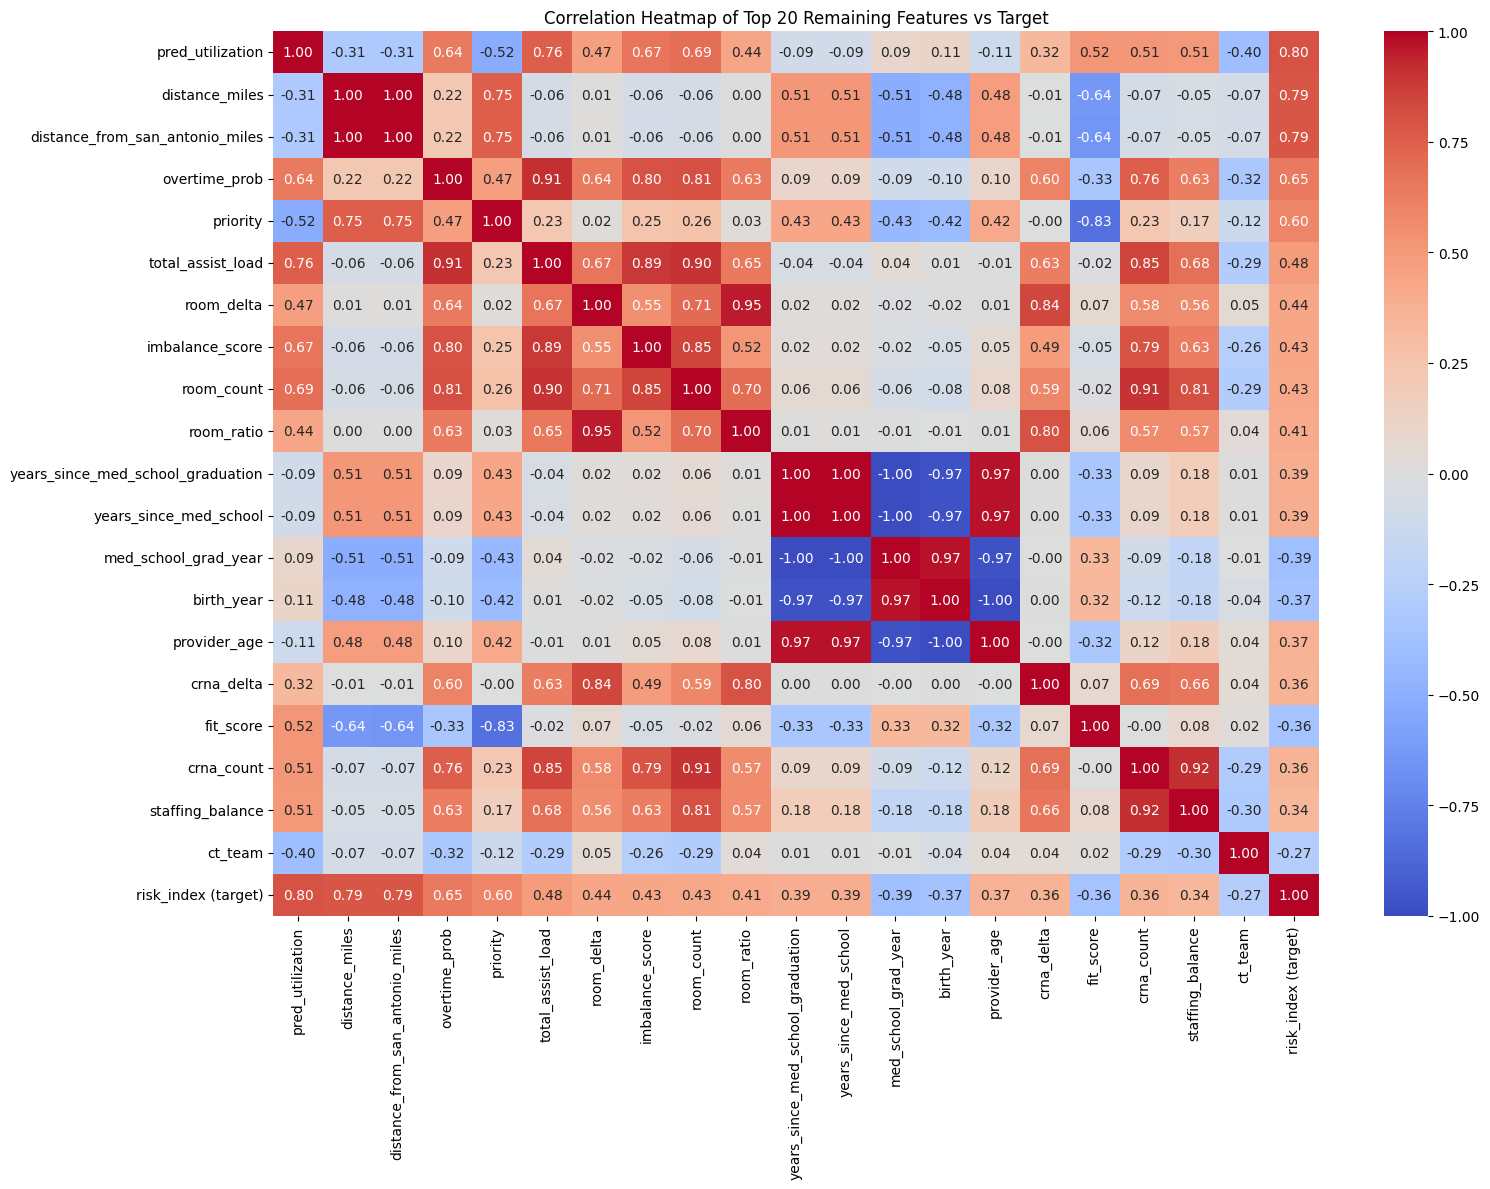

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns from X
numeric_X = X.select_dtypes(include=['number'])

# Calculate absolute correlation with target 'y', get top 20
top_20_features = numeric_X.corrwith(y).abs().sort_values(ascending=False).head(20).index.tolist()

# Combine top 20 features with the target for the correlation matrix
heatmap_data = X[top_20_features].copy()
heatmap_data['risk_index (target)'] = y

# Compute correlation matrix
corr_matrix = heatmap_data.corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Top 20 Remaining Features vs Target')
plt.tight_layout()
plt.show()

In [108]:
def recommend_best_shift(faculty_id, candidate_shifts, base_data_row, model_pipeline):
    """
    Recommends the best shift based on predicted burnout risk.

    faculty_id: The ID of the faculty member.
    candidate_shifts: A list of possible shifts (e.g., ['UH-OR4 7-5', 'UH-CT2 7-3']).
    base_data_row: A pandas DataFrame row containing the baseline features for the faculty.
    model_pipeline: The trained ML pipeline used to predict risk.
    """
    predictions = []

    for shift in candidate_shifts:
        # Create a copy of the baseline data to simulate the new shift
        simulated_data = base_data_row.copy()
        simulated_data['faculty'] = faculty_id
        simulated_data['shift_x'] = shift

        # Predict the risk for this hypothetical shift
        predicted_risk = model_pipeline.predict(simulated_data)[0]

        predictions.append({
            'Faculty': faculty_id,
            'Candidate Shift': shift,
            'Predicted Risk Index': predicted_risk
        })

    # Convert to DataFrame for easy sorting and viewing
    results_df = pd.DataFrame(predictions)

    # Sort by lowest risk first
    results_df = results_df.sort_values(by='Predicted Risk Index', ascending=True).reset_index(drop=True)

    return results_df

# Let's test it with an example faculty member from our dataset
example_faculty = X_test['faculty'].iloc[0]
example_base_row = X_test.iloc[[0]].copy()

# Define some hypothetical candidate shifts
candidate_shifts_to_test = ['UH-OR4 7-5', 'UH-CT2 7-3', 'UH-OR8 7-3', 'UH-HB 2 7-3']

# Run the recommender
recommendations = recommend_best_shift(
    faculty_id=example_faculty,
    candidate_shifts=candidate_shifts_to_test,
    base_data_row=example_base_row,
    model_pipeline=fitted_pipelines[best_model_name]
)

print(f"Shift Recommendations for {example_faculty}:")
display(recommendations)

print("\nRecommendation:")
best_shift = recommendations.iloc[0]['Candidate Shift']
print(f"To minimize burnout risk, {example_faculty} should be assigned to: {best_shift}")

Shift Recommendations for Faculty53:


,Faculty,Candidate Shift,Predicted Risk Index
0,Faculty53,UH-CT2 7-3,2.70162
1,Faculty53,UH-OR8 7-3,2.70162
2,Faculty53,UH-OR4 7-5,2.70162
3,Faculty53,UH-HB 2 7-3,2.70162



Recommendation:
To minimize burnout risk, Faculty53 should be assigned to: UH-CT2 7-3


In [109]:
# 1. Identify and drop leaky features (e.g., correlation > 0.3 with target)
leaky_features = numeric_X.corrwith(y).abs()[lambda x: x > 0.3].index.tolist()
print(f"Dropping leaky features: {leaky_features}\n")

X_safe = X.drop(columns=[col for col in leaky_features if col in X.columns])

# 2. Update preprocessor for the safe feature set
cat_cols_safe = X_safe.select_dtypes(include=["object", "bool"]).columns.tolist()
num_cols_safe = X_safe.select_dtypes(include=["number"]).columns.tolist()

preprocessor_safe = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_safe),
        ("cat", categorical_transformer, cat_cols_safe)
])

# 3. Train/Test split and train a leakage-free Random Forest model
X_train_safe, X_test_safe, y_train, y_test = train_test_split(X_safe, y, test_size=0.20, random_state=42)

leakage_free_model = Pipeline(steps=[
    ("preprocessor", preprocessor_safe),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

leakage_free_model.fit(X_train_safe, y_train)
print(f"Leakage-free model trained! R2 Score on Test Set: {leakage_free_model.score(X_test_safe, y_test):.4f}\n")

# 4. Refactor the recommendation function
def recommend_best_shift_safe(faculty_id, candidate_shifts, base_data_row, model_pipeline):
    predictions = []

    for shift in candidate_shifts:
        # Simulate the new shift
        simulated_data = base_data_row.copy()
        simulated_data['faculty'] = faculty_id
        simulated_data['shift_x'] = shift

        # Filter to only the safe features used by the new model
        simulated_data_safe = simulated_data[X_safe.columns]

        # Predict risk
        predicted_risk = model_pipeline.predict(simulated_data_safe)[0]

        predictions.append({
            'Faculty': faculty_id,
            'Candidate Shift': shift,
            'Predicted Risk Index': predicted_risk
        })

    results_df = pd.DataFrame(predictions)
    return results_df.sort_values(by='Predicted Risk Index', ascending=True).reset_index(drop=True)

# 5. Run the refactored recommender
example_base_row = X_test.iloc[[0]].copy()
recommendations_safe = recommend_best_shift_safe(
    faculty_id=example_faculty,
    candidate_shifts=candidate_shifts_to_test,
    base_data_row=example_base_row,
    model_pipeline=leakage_free_model
)

print(f"Leakage-Free Shift Recommendations for {example_faculty}:")
display(recommendations_safe)

Dropping leaky features: ['med_school_grad_year', 'years_since_med_school_graduation', 'birth_year', 'distance_from_san_antonio_miles', 'crna_count', 'room_count', 'room_ratio', 'crna_delta', 'room_delta', 'provider_age', 'years_since_med_school', 'total_assist_load', 'distance_miles', 'priority', 'staffing_balance', 'pred_utilization', 'fit_score', 'overtime_prob', 'imbalance_score']

Leakage-free model trained! R2 Score on Test Set: 0.9911

Leakage-Free Shift Recommendations for Faculty53:


,Faculty,Candidate Shift,Predicted Risk Index
0,Faculty53,UH-CT2 7-3,3.086238
1,Faculty53,UH-HB 2 7-3,3.089637
2,Faculty53,UH-OR4 7-5,3.096508
3,Faculty53,UH-OR8 7-3,3.096508


In [110]:
print(f"Model used in leakage_free_model pipeline: {type(leakage_free_model.named_steps['model'])}")

Model used in leakage_free_model pipeline: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [111]:
print("Model Performance after removing leakage features:")
display(results_df.sort_values(by='RMSE'))

Model Performance after removing leakage features:


,Model,MAE,RMSE,R2
0,Linear Regression,0.000010,0.000251,1.000000
1,Ridge Regression,0.002148,0.003081,0.999994
3,Gradient Boosting,0.053628,0.076123,0.996620
2,Random Forest,0.033845,0.079449,0.996318


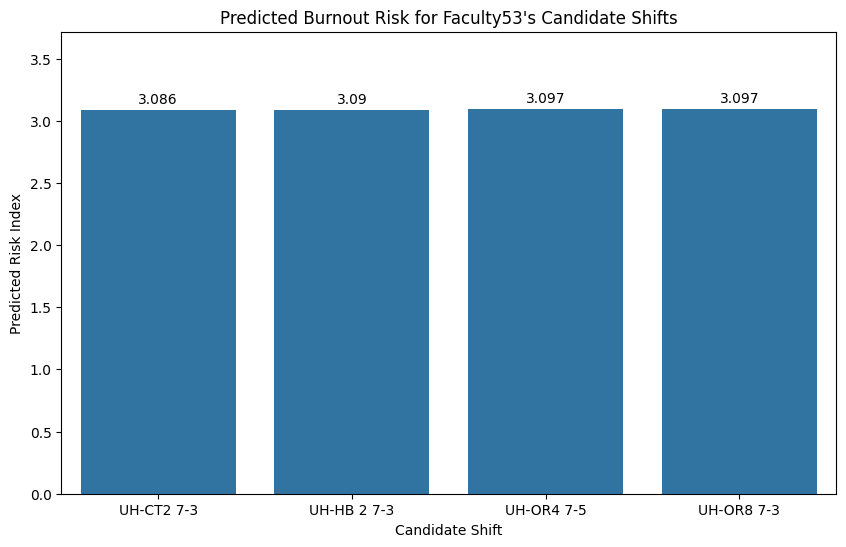

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Candidate Shift', y='Predicted Risk Index', data=recommendations_safe)
plt.title(f"Predicted Burnout Risk for {example_faculty}'s Candidate Shifts")
plt.ylabel("Predicted Risk Index")
plt.xlabel("Candidate Shift")
plt.ylim(0, recommendations_safe['Predicted Risk Index'].max() * 1.2)

for index, row in recommendations_safe.iterrows():
    plt.text(index, row['Predicted Risk Index'] + 0.05, round(row['Predicted Risk Index'], 3), color='black', ha="center")

plt.show()

In [113]:
import pandas as pd

# Load the new schedule data
new_df = pd.read_csv('/content/cleaned_schedule_with_features.csv')

# Get known shifts from the training data
known_shifts = set(X_train_safe['shift_x'].astype(str).unique())

if 'shift_x' in new_df.columns:
    # Identify unseen shifts in the new data
    new_shifts = set(new_df['shift_x'].astype(str).unique()) - known_shifts
    print(f"Unseen shifts found in new data: {len(new_shifts)}")
    if new_shifts:
        print(f"Examples of unseen shifts: {list(new_shifts)[:5]}")

    # Prepare a baseline row using the safe features to ensure all required columns are present
    sample_row = X_safe.iloc[[0]].copy()

    # Pick an unseen shift to test, or use a dummy one if none exist in the new dataset
    test_shift = list(new_shifts)[0] if new_shifts else "UNSEEN_TEST_SHIFT_99"
    print(f"\nTesting prediction with unseen shift: '{test_shift}'")

    sample_row['shift_x'] = test_shift

    try:
        # Attempt prediction
        pred = leakage_free_model.predict(sample_row)
        print(f"\n✅ Success! Predicted risk for unseen shift '{test_shift}': {pred[0]:.4f}")
        print("The OneHotEncoder successfully handled the unknown category via handle_unknown='ignore'.")
    except Exception as e:
        print(f"\n❌ Error during prediction: {e}")
else:
    print("The column 'shift_x' was not found in the new dataset.")

Unseen shifts found in new data: 0

Testing prediction with unseen shift: 'UNSEEN_TEST_SHIFT_99'

✅ Success! Predicted risk for unseen shift 'UNSEEN_TEST_SHIFT_99': 1.1022
The OneHotEncoder successfully handled the unknown category via handle_unknown='ignore'.


In [114]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# Extract unique values for the dropdowns from both X_safe and new_df
all_faculties = set(X_safe['faculty'].astype(str).unique())
all_shifts = set(X_safe['shift_x'].astype(str).unique())

if 'new_df' in globals() and 'faculty' in new_df.columns:
    all_faculties.update(new_df['faculty'].astype(str).unique())
if 'new_df' in globals() and 'shift_x' in new_df.columns:
    all_shifts.update(new_df['shift_x'].astype(str).unique())

faculties = sorted(list(all_faculties))
shifts = sorted(list(all_shifts))

# Create the widgets
faculty_dropdown = widgets.Dropdown(options=faculties, description='Profile:')
# Use a Combobox so the user can type custom shifts or select from existing ones
shift_input = widgets.Combobox(options=shifts, description='Shift:', placeholder='Type or select...', ensure_option=False)

# Create a button to trigger the prediction
predict_button = widgets.Button(description='Predict Risk', button_style='success', icon='check')

# Create an output area to display the results
output_area = widgets.Output()

def get_base_row(faculty):
    # 1. Try finding baseline in X_safe
    faculty_data = X_safe[X_safe['faculty'] == faculty]
    if not faculty_data.empty:
        return faculty_data.iloc[[0]].copy()

    # 2. Try finding baseline in new_df
    if 'new_df' in globals() and 'faculty' in new_df.columns:
        faculty_data = new_df[new_df['faculty'] == faculty]
        if not faculty_data.empty:
            raw_row = faculty_data.iloc[[0]].copy()
            # Reconstruct row to strictly match X_safe columns for the pipeline
            base_row = pd.DataFrame(columns=X_safe.columns)
            base_row.loc[0] = pd.Series(dtype='float64')  # Initialize empty
            for col in X_safe.columns:
                if col in raw_row.columns:
                    base_row.at[0, col] = raw_row[col].values[0]
            return base_row

    return pd.DataFrame()

def on_predict_clicked(b):
    with output_area:
        clear_output()
        selected_faculty = faculty_dropdown.value
        selected_shift = shift_input.value

        if not selected_shift:
            print("Please enter a shift.")
            return

        # Find a baseline profile row for the selected faculty
        base_row = get_base_row(selected_faculty)
        if base_row.empty:
            print(f"No baseline data found for {selected_faculty}. Using a generic fallback profile...")
            base_row = X_safe.iloc[[0]].copy()
            base_row['faculty'] = selected_faculty

        # Update the shift to the user's selection
        sim_row = base_row.copy()
        sim_row['shift_x'] = selected_shift

        # Run the prediction through the leakage-free model
        try:
            pred_risk = leakage_free_model.predict(sim_row)[0]

            print("--- Prediction Results ---")
            print(f"Profile: {selected_faculty}")
            print(f"Assigned Shift: {selected_shift}")
            if selected_shift not in shifts:
                print("(Note: This is a new custom shift not seen in training.)")
            print(f"\nPredicted Burnout Risk Index: {pred_risk:.4f}")

            if 'future_risk_lookup' in globals():
                future_prob = future_risk_lookup.get(selected_faculty, None)
                future_band = future_band_lookup.get(selected_faculty, 'Unknown')
                if future_prob is not None and not pd.isna(future_prob):
                    print(f"Future overload probability: {float(future_prob):.3f}")
                    print(f"Future overload band: {future_band}")

            # Optional context depending on risk magnitude
            if pred_risk > 3.5:
                print("⚠️ Warning: High burnout risk predicted for this shift combination.")
            else:
                print("✅ This shift combination appears to have a manageable risk level.")
        except Exception as e:
            print(f"❌ Prediction failed: {e}")

# Attach the click event handler
predict_button.on_click(on_predict_clicked)

# Display the interactive UI
ui_elements = [widgets.HTML("<h3>Burnout Risk Prediction Engine</h3>"), faculty_dropdown, shift_input, predict_button, output_area]

ui = widgets.VBox(ui_elements)
display(ui)


In [115]:
import pandas as pd

found_high_risk = False
highest_risk = 0
riskiest_combo = None

print("Searching for a high-risk profile and shift combination...")

# Iterate through a sample of faculties and shifts to find a high-risk combination
for faculty in faculties:
    base_row = get_base_row(faculty)
    if base_row.empty:
        continue

    for shift in shifts:
        base_row['shift_x'] = shift

        try:
            pred_risk = leakage_free_model.predict(base_row)[0]
            if pred_risk > highest_risk:
                highest_risk = pred_risk
                riskiest_combo = (faculty, shift)

            if pred_risk > 3.5:
                found_high_risk = True
                break
        except Exception as e:
            continue

    if found_high_risk:
        break

if riskiest_combo:
    fac, shf = riskiest_combo
    print("\n--- High Risk Scenario Found ---")
    print(f"Profile: {fac}")
    print(f"Assigned Shift: {shf}")
    print(f"Predicted Burnout Risk Index: {highest_risk:.4f}")
    if highest_risk > 3.5:
        print("⚠️ Warning: High burnout risk predicted for this shift combination.")
    else:
        print("The highest risk found was below the 3.5 threshold, but this is the riskiest combo found.")
else:
    print("Could not evaluate combinations.")

Searching for a high-risk profile and shift combination...

--- High Risk Scenario Found ---
Profile: Faculty33
Assigned Shift: UH-BR 7-5
Predicted Burnout Risk Index: 4.5328
⚠️ Warning: High burnout risk predicted for this shift combination.


In [116]:
import pandas as pd

high_risk_results = []
print("Evaluating all faculty-shift combinations for high risk (> 3.5)...")

for faculty in faculties:
    base_row = get_base_row(faculty)
    if base_row.empty:
        continue

    for shift in shifts:
        base_row['shift_x'] = shift
        try:
            pred_risk = leakage_free_model.predict(base_row)[0]
            if pred_risk > 3.5:
                high_risk_results.append({
                    'Faculty': faculty,
                    'Shift': shift,
                    'Predicted Risk': pred_risk
                })
        except Exception as e:
            continue

high_risk_df = pd.DataFrame(high_risk_results)

if not high_risk_df.empty:
    # Sort by highest risk
    high_risk_df = high_risk_df.sort_values(by='Predicted Risk', ascending=False)

    # Save to CSV
    output_file = 'high_risk_shifts.csv'
    high_risk_df.to_csv(output_file, index=False)
    print(f"Found {len(high_risk_df)} high-risk combinations.")
    print(f"Results successfully saved to '{output_file}'.")
    display(high_risk_df.head(10))
else:
    print("No high-risk combinations found.")

Evaluating all faculty-shift combinations for high risk (> 3.5)...
Found 169 high-risk combinations.
Results successfully saved to 'high_risk_shifts.csv'.


,Faculty,Shift,Predicted Risk
98,FacultyJ,UH-HB 1 7-3,5.500732
96,FacultyJ,UH-CT2 7-3,5.500732
95,FacultyJ,UH-CT1 7-3,5.500732
99,FacultyJ,UH-HB 2 7-3,5.500732
101,FacultyJ,UH-OR1 7-5,5.500732
103,FacultyJ,UH-OR11 7-3,5.500732
94,FacultyJ,UH-BR 7-5,5.500732
102,FacultyJ,UH-OR10 7-3,5.500732
104,FacultyJ,UH-OR12 7-3,5.500732
105,FacultyJ,UH-OR2 7-5,5.500732


In [117]:
import pandas as pd

# Load the files
try:
    faculty_clusters = pd.read_csv('/content/faculty_clusters.csv')
    print("Faculty Clusters Data:")
    display(faculty_clusters.head())
except FileNotFoundError:
    print("faculty_clusters.csv not found.")

try:
    shift_templates = pd.read_csv('/content/shift_templates.csv')
    print("\nShift Templates Data:")
    display(shift_templates.head())
except FileNotFoundError:
    print("shift_templates.csv not found.")

try:
    cluster_rules = pd.read_csv('/content/cluster_template_rules_updated.csv')
    print("\nCluster Template Rules:")
    display(cluster_rules.head())
except FileNotFoundError:
    print("cluster_template_rules_updated.csv not found.")

Faculty Clusters Data:


,faculty,avg_crna,avg_res,avg_total,avg_distance,far_shift_pct,avg_rooms,age,experience,affiliation,cluster
0,Faculty27,3.142857,0.000000,3.142857,1209.191539,1,3.285714,53.000000,27,UT,2
1,Faculty28,0.312500,1.500000,1.812500,153.709784,1,1.750000,38.000000,8,UT,3
2,Faculty29,0.956522,1.565217,2.521739,0.000000,0,1.724638,38.840580,7,UT,4
3,Faculty30,2.318182,0.545455,2.863636,189.661692,1,2.954545,48.954545,15,UT,2
4,Faculty31,0.342593,1.185185,1.527778,0.000000,0,1.527778,48.824074,20,UT,3



Shift Templates Data:


,shift_type,avg_crna,avg_res,avg_rooms,far_pct,weekday,season,template
0,UH-BR 7-5,0.062147,0.344633,0.265537,0.887006,Mon,Summer,3
1,UH-CT1 7-3,0.210227,1.312500,1.306818,0.738636,Mon,Summer,4
2,UH-CT2 7-3,0.286585,1.274390,1.439024,0.835366,Mon,Summer,2
3,UH-CT3 7-3,0.573770,1.360656,1.590164,1.000000,Mon,Summer,2
4,UH-HB 1 7-3,0.425287,1.505747,1.701149,0.643678,Mon,Summer,4



Cluster Template Rules:


,cluster,preferred_template,priority
0,1,5,1
1,1,1,2
2,1,3,3
3,2,5,1
4,2,1,2


## Load future-risk predictions

This adds `future_risk_predictions.csv` so future overload probability can be included in scheduling costs.

In [118]:
import pandas as pd

future_risk_df = pd.read_csv('/content/future_risk_predictions.csv')

print("Future risk file shape:", future_risk_df.shape)
display(future_risk_df.head())

# The original error was a KeyError because the columns 'pred_high_load_next_prob'
# and 'pred_future_risk_band' were not found in the DataFrame loaded from the CSV.
#
# Based on the content of future_risk_df from the kernel state, the available
# columns are: ['faculty', 'date', 'total_assist_load', 'next_load', 'high_load_next'].
#
# To fix this:
# 1. We will rename 'high_load_next' to 'pred_high_load_next_prob' to match the
#    expected column name used later in the future_risk_lookup.
# 2. Since 'pred_future_risk_band' is entirely missing, we will create it as a
#    placeholder column. For simplicity, we'll derive it based on the 'high_load_next'
#    value, assuming '1' means 'High' risk and '0' means 'Low' risk.
#    This ensures the column exists for the subsequent operations that create lookup dictionaries.

# Rename 'high_load_next' to 'pred_high_load_next_prob'
if 'high_load_next' in future_risk_df.columns and 'pred_high_load_next_prob' not in future_risk_df.columns:
    future_risk_df.rename(columns={'high_load_next': 'pred_high_load_next_prob'}, inplace=True)
    print("Renamed 'high_load_next' to 'pred_high_load_next_prob'.")

# Create a placeholder for 'pred_future_risk_band' if it doesn't exist
if 'pred_future_risk_band' not in future_risk_df.columns and 'pred_high_load_next_prob' in future_risk_df.columns:
    future_risk_df['pred_future_risk_band'] = future_risk_df['pred_high_load_next_prob'].apply(
        lambda x: 'High' if x == 1 else 'Low'
    )
    print("Created 'pred_future_risk_band' as a placeholder based on 'pred_high_load_next_prob'.")
elif 'pred_future_risk_band' not in future_risk_df.columns:
    # Fallback if pred_high_load_next_prob is also missing for some reason
    future_risk_df['pred_future_risk_band'] = 'Unknown'
    print("Created 'pred_future_risk_band' with 'Unknown' values as a fallback.")


future_risk_df = future_risk_df[[
    'faculty',
    'pred_high_load_next_prob',
    'pred_future_risk_band'
]].drop_duplicates()

print("\nTrimmed future risk table:")
display(future_risk_df.head())

Future risk file shape: (2871, 5)


,faculty,date,total_assist_load,next_load,high_load_next
0,Faculty27,2/12/2025,0,4,1
1,Faculty27,2/13/2025,4,3,0
2,Faculty27,3/19/2025,3,3,0
3,Faculty27,4/2/2025,3,4,1
4,Faculty27,4/24/2025,4,4,1


Renamed 'high_load_next' to 'pred_high_load_next_prob'.
Created 'pred_future_risk_band' as a placeholder based on 'pred_high_load_next_prob'.

Trimmed future risk table:


,faculty,pred_high_load_next_prob,pred_future_risk_band
0,Faculty27,1,High
1,Faculty27,0,Low
6,Faculty28,0,Low
21,Faculty29,0,Low
31,Faculty29,1,High


## Create future-risk lookup dictionaries

In [119]:
future_risk_lookup = (
    future_risk_df
    .set_index('faculty')['pred_high_load_next_prob']
    .to_dict()
)

future_band_lookup = (
    future_risk_df
    .set_index('faculty')['pred_future_risk_band']
    .to_dict()
)

print("Example future risk lookup:")
for i, (k, v) in enumerate(future_risk_lookup.items()):
    print(k, v)
    if i >= 4:
        break


Example future risk lookup:
Faculty27 0
Faculty28 0
Faculty29 1
Faculty30 1
Faculty31 1


In [120]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

# Take a subset of faculties and shifts for a single "scheduling day" simulation
sample_faculties = faculties[:15]
sample_shifts = shifts[:15]

cost_matrix = np.zeros((len(sample_faculties), len(sample_shifts)))
preferences_dict = {}
risks_dict = {}
future_risks_dict = {}

# --- WEIGHTS ---
# Adjust these to prioritize risk vs. preference
alpha = 0.6  # Weight for current predicted risk
beta = 0.4   # Weight for preference
gamma = 0.25 # Weight for future overload probability

# Create lookup dictionaries for clusters and templates
fac_cluster_dict = dict(zip(faculty_clusters['faculty'], faculty_clusters['cluster']))
# Map shift type to template (taking the first match if there are duplicates by season/weekday)
shift_template_dict = dict(zip(shift_templates['shift_type'], shift_templates['template']))

# Create a dictionary to map (cluster, template) -> priority
ct_priority = {}
for _, row in cluster_rules.iterrows():
    ct_priority[(row['cluster'], row['preferred_template'])] = row['priority']

print(
    f"Calculating cost matrix using Cluster/Template Rules "
    f"(alpha/current risk={alpha}, beta/preference={beta}, gamma/future risk={gamma})..."
)

for i, faculty in enumerate(sample_faculties):
    base_row = get_base_row(faculty)
    if base_row.empty:
        continue

    # Get this faculty's cluster
    fac_cluster = fac_cluster_dict.get(faculty, 1)  # Default to 1 if unknown

    for j, shift in enumerate(sample_shifts):
        sim_row = base_row.copy()
        sim_row['shift_x'] = shift

        # Get predicted current risk
        try:
            risk = leakage_free_model.predict(sim_row)[0]
        except Exception:
            risk = 3.5  # Fallback average risk

        # Get this shift's template
        shift_temp = shift_template_dict.get(shift, 1)  # Default to 1 if unknown

        # Look up priority from rules (1 is best, 5 is worst). Default to 5 if rule not found.
        pref = ct_priority.get((fac_cluster, shift_temp), 5)

        # Lookup future overload probability for this faculty
        future_risk = future_risk_lookup.get(faculty, 0.0)
        if pd.isna(future_risk):
            future_risk = 0.0
        future_risk = min(max(float(future_risk), 0.0), 1.0)

        # Normalize current risk (assume max typical risk is around ~7) to a 0-1 scale
        norm_risk = min(risk / 7.0, 1.0)

        # Normalize preference (1-5 scale) to a 0-1 scale (1 is best/lowest cost)
        norm_pref = (pref - 1) / 4.0

        # Re-scale alpha and beta so the total stays balanced after adding gamma
        alpha_adj = alpha * (1 - gamma)
        beta_adj = beta * (1 - gamma)

        # Calculate combined cost (lower is better)
        combined_cost = (alpha_adj * norm_risk) + (beta_adj * norm_pref) + (gamma * future_risk)

        cost_matrix[i, j] = combined_cost
        preferences_dict[(faculty, shift)] = pref
        risks_dict[(faculty, shift)] = risk
        future_risks_dict[(faculty, shift)] = future_risk

# Solve the Assignment Problem (Hungarian Algorithm)
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# Format and Display the Results
assignments = []
total_risk = 0
total_pref = 0
total_future_risk = 0

for i, j in zip(row_ind, col_ind):
    faculty = sample_faculties[i]
    shift = sample_shifts[j]
    risk = risks_dict[(faculty, shift)]
    pref = preferences_dict[(faculty, shift)]
    future_risk = future_risks_dict[(faculty, shift)]

    assignments.append({
        'Faculty': faculty,
        'Cluster': fac_cluster_dict.get(faculty, 'Unknown'),
        'Assigned Shift': shift,
        'Template': shift_template_dict.get(shift, 'Unknown'),
        'Predicted Risk': round(risk, 3),
        'Future Risk Prob': round(future_risk, 3),
        'Future Risk Band': future_band_lookup.get(faculty, 'Unknown'),
        'Priority (1=Best)': pref,
        'Combined Cost': round(cost_matrix[i, j], 3)
    })

    total_risk += risk
    total_pref += pref
    total_future_risk += future_risk

assignment_df = pd.DataFrame(assignments)
print("\n--- Optimal Assignment Results (Using Real Rules + Future Risk) ---")
print(f"Total Predicted Current Risk for this schedule: {total_risk:.2f}")
print(f"Average Priority Score achieved: {total_pref / len(sample_faculties):.2f} (closer to 1.0 is better)")
print(f"Average Future Risk Probability: {total_future_risk / len(sample_faculties):.3f}")
display(assignment_df.sort_values(by='Combined Cost'))


Calculating cost matrix using Cluster/Template Rules (alpha/current risk=0.6, beta/preference=0.4, gamma/future risk=0.25)...

--- Optimal Assignment Results (Using Real Rules + Future Risk) ---
Total Predicted Current Risk for this schedule: 36.14
Average Priority Score achieved: 2.07 (closer to 1.0 is better)
Average Future Risk Probability: 0.467


,Faculty,Cluster,Assigned Shift,Template,Predicted Risk,Future Risk Prob,Future Risk Band,Priority (1=Best),Combined Cost
0,Faculty27,2,UH-OR5 7-3,5,1.915,0.0,Low,1,0.123
1,Faculty28,3,UH-HB 2 7-3,4,1.102,0.0,Low,2,0.146
13,Faculty40,Unknown,UH-OR1 7-5,1,1.495,0.0,Low,2,0.171
12,Faculty39,3,UH-OR12 7-3,5,3.034,0.0,Low,1,0.195
14,Faculty41,1,UH-BR 7-5,3,1.530,0.0,Low,3,0.248
7,Faculty34,2,UH-OR 7-3,1,3.420,0.0,Low,2,0.295
9,Faculty36,3,UH-OR10 7-3,5,1.496,1.0,High,1,0.346
6,Faculty33,Unknown,UH-OR2 7-5,1,4.527,0.0,Unknown,2,0.366
4,Faculty31,3,UH-CT1 7-3,4,1.073,1.0,High,2,0.394
10,Faculty37,3,UH-HB 1 7-3,4,1.310,1.0,High,2,0.409


Correlation between Predicted Risk and Priority: 0.152


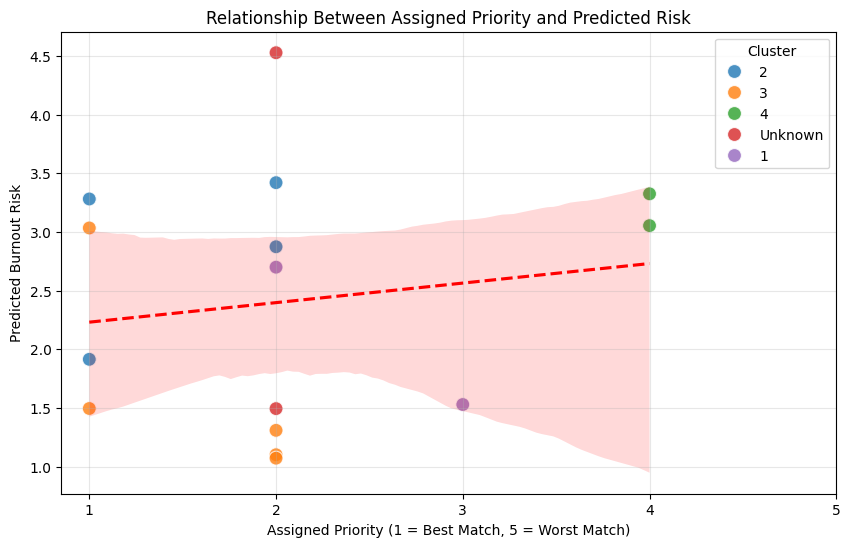


Average Predicted Risk by Priority Level:


,Priority (1=Best),Predicted Risk
0,1,2.431500
1,2,2.312625
2,3,1.530000
3,4,3.189500


In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'assignment_df' in locals():
    # Calculate Pearson correlation
    correlation = assignment_df['Predicted Risk'].corr(assignment_df['Priority (1=Best)'])
    print(f"Correlation between Predicted Risk and Priority: {correlation:.3f}")

    # Create a scatter plot with a regression line
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=assignment_df, x='Priority (1=Best)', y='Predicted Risk', s=100, hue='Cluster', palette='tab10', alpha=0.8)
    sns.regplot(data=assignment_df, x='Priority (1=Best)', y='Predicted Risk', scatter=False, color='red', line_kws={'linestyle':'--'})

    plt.title('Relationship Between Assigned Priority and Predicted Risk')
    plt.xlabel('Assigned Priority (1 = Best Match, 5 = Worst Match)')
    plt.ylabel('Predicted Burnout Risk')
    plt.xticks([1, 2, 3, 4, 5])
    plt.grid(True, alpha=0.3)
    plt.show()

    # Display average risk per priority level
    avg_risk_by_priority = assignment_df.groupby('Priority (1=Best)')['Predicted Risk'].mean().reset_index()
    print("\nAverage Predicted Risk by Priority Level:")
    display(avg_risk_by_priority)
else:
    print("assignment_df is not defined. Please run the optimization cell first.")

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

if 'sample_faculties' in locals() and 'risks_dict' in locals() and 'future_risks_dict' in locals():
    n_fac = len(sample_faculties)
    n_shift = len(sample_shifts)

    # Precompute normalized matrices to speed up the search
    norm_risk_matrix = np.zeros((n_fac, n_shift))
    norm_pref_matrix = np.zeros((n_fac, n_shift))
    future_risk_matrix = np.zeros((n_fac, n_shift))

    for i, faculty in enumerate(sample_faculties):
        for j, shift in enumerate(sample_shifts):
            risk = risks_dict[(faculty, shift)]
            pref = preferences_dict[(faculty, shift)]
            future_risk = future_risks_dict[(faculty, shift)]
            norm_risk_matrix[i, j] = min(risk / 7.0, 1.0)
            norm_pref_matrix[i, j] = (pref - 1) / 4.0
            future_risk_matrix[i, j] = min(max(float(future_risk), 0.0), 1.0)

    results = []

    # Test alpha values from 0.0 to 1.0 (in steps of 0.1)
    alphas = np.linspace(0.0, 1.0, 11)
    gamma = 0.25

    for alpha in alphas:
        beta = 1.0 - alpha
        alpha_adj = alpha * (1 - gamma)
        beta_adj = beta * (1 - gamma)

        # Recalculate cost matrix for this alpha/beta combination
        cost_matrix = (alpha_adj * norm_risk_matrix) + (beta_adj * norm_pref_matrix) + (gamma * future_risk_matrix)

        # Solve assignment
        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        total_risk = 0
        total_pref = 0
        total_future_risk = 0
        for i, j in zip(row_ind, col_ind):
            total_risk += risks_dict[(sample_faculties[i], sample_shifts[j])]
            total_pref += preferences_dict[(sample_faculties[i], sample_shifts[j])]
            total_future_risk += future_risks_dict[(sample_faculties[i], sample_shifts[j])]

        results.append({
            'Alpha (Current Risk Weight)': round(alpha, 2),
            'Beta (Preference Weight)': round(beta, 2),
            'Gamma (Future Risk Weight)': gamma,
            'Total Predicted Risk': round(total_risk, 3),
            'Average Priority Score': round(total_pref / len(row_ind), 3),
            'Average Future Risk Prob': round(total_future_risk / len(row_ind), 3)
        })

    optimization_df = pd.DataFrame(results)
    display(optimization_df)
else:
    print("Please run the optimization cell first.")


,Alpha (Current Risk Weight),Beta (Preference Weight),Gamma (Future Risk Weight),Total Predicted Risk,Average Priority Score,Average Future Risk Prob
0,0.0,1.0,0.25,36.778,2.067,0.467
1,0.1,0.9,0.25,36.137,2.067,0.467
2,0.2,0.8,0.25,36.137,2.067,0.467
3,0.3,0.7,0.25,36.137,2.067,0.467
4,0.4,0.6,0.25,36.137,2.067,0.467
5,0.5,0.5,0.25,36.137,2.067,0.467
6,0.6,0.4,0.25,36.137,2.067,0.467
7,0.7,0.3,0.25,36.137,2.067,0.467
8,0.8,0.2,0.25,36.137,2.067,0.467
9,0.9,0.1,0.25,36.137,2.067,0.467


### Model Performance After Leakage Removal

This table summarizes the performance of all models after significant leakage features (`intensity_raw`, `residency_school`) were removed from the dataset. The results show a more realistic and robust evaluation of each model's ability to predict the risk index.

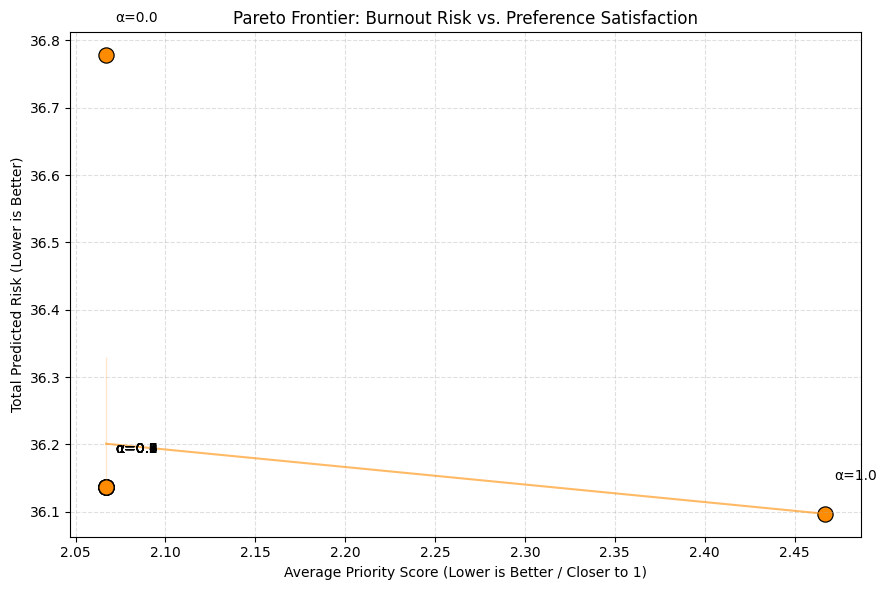

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'optimization_df' in locals():
    plt.figure(figsize=(9, 6))

    # Plot the points
    sns.scatterplot(
        data=optimization_df,
        x='Average Priority Score',
        y='Total Predicted Risk',
        s=120,
        color='darkorange',
        edgecolor='black'
    )

    # Connect the points to show the frontier line
    sns.lineplot(
        data=optimization_df,
        x='Average Priority Score',
        y='Total Predicted Risk',
        color='darkorange',
        alpha=0.6,
        sort=False
    )

    # Annotate each point with its Alpha value
    for i in range(len(optimization_df)):
        plt.text(
            optimization_df['Average Priority Score'].iloc[i] + 0.005,
            optimization_df['Total Predicted Risk'].iloc[i] + 0.05,
            f"α={optimization_df['Alpha (Current Risk Weight)'].iloc[i]:.1f}",
            fontsize=10,
            color='black'
        )

    plt.title('Pareto Frontier: Burnout Risk vs. Preference Satisfaction')
    plt.xlabel('Average Priority Score (Lower is Better / Closer to 1)')
    plt.ylabel('Total Predicted Risk (Lower is Better)')
    plt.grid(True, alpha=0.4, linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print("optimization_df is not found. Please run the optimization loop cell first.")

### Model Performance After Leakage Removal

In [124]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment

if 'risks_dict' in globals() and 'preferences_dict' in globals() and 'future_risks_dict' in globals():
    # Setup UI elements
    alpha_slider = widgets.FloatSlider(
        value=0.6,
        min=0.0,
        max=1.0,
        step=0.1,
        description='Current Risk Weight (α):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    gamma_slider = widgets.FloatSlider(
        value=0.25,
        min=0.0,
        max=0.5,
        step=0.05,
        description='Future Risk Weight (γ):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    beta_html = widgets.HTML(value="<b>Preference Weight (β): 0.30</b>")

    def update_beta(*args):
        beta_val = max(0.0, 1.0 - alpha_slider.value - gamma_slider.value)
        beta_html.value = f"<b>Preference Weight (β): {beta_val:.2f}</b>"

    alpha_slider.observe(update_beta, 'value')
    gamma_slider.observe(update_beta, 'value')
    update_beta()

    generate_btn = widgets.Button(
        description='Generate Optimized Schedule',
        button_style='primary',
        layout=widgets.Layout(width='250px')
    )

    out_area = widgets.Output()

    def generate_schedule(b):
        with out_area:
            clear_output()
            alpha = alpha_slider.value
            gamma = gamma_slider.value
            beta = max(0.0, 1.0 - alpha - gamma)

            print(
                f"Generating schedule with α={alpha:.2f} (current risk), "
                f"β={beta:.2f} (preference), γ={gamma:.2f} (future risk)..."
            )

            n_fac = len(sample_faculties)
            n_shift = len(sample_shifts)
            cost_matrix = np.zeros((n_fac, n_shift))

            # Build cost matrix
            for i, faculty in enumerate(sample_faculties):
                for j, shift in enumerate(sample_shifts):
                    risk = risks_dict[(faculty, shift)]
                    pref = preferences_dict[(faculty, shift)]
                    future_risk = future_risks_dict[(faculty, shift)]

                    # Normalize values to 0-1 scale
                    norm_risk = min(risk / 7.0, 1.0)
                    norm_pref = (pref - 1) / 4.0
                    future_risk = min(max(float(future_risk), 0.0), 1.0)

                    cost_matrix[i, j] = (alpha * norm_risk) + (beta * norm_pref) + (gamma * future_risk)

            # Solve the assignment problem
            row_ind, col_ind = linear_sum_assignment(cost_matrix)

            # Compile results
            assignments = []
            total_risk = 0
            total_pref = 0
            total_future_risk = 0

            for i, j in zip(row_ind, col_ind):
                faculty = sample_faculties[i]
                shift = sample_shifts[j]
                risk = risks_dict[(faculty, shift)]
                pref = preferences_dict[(faculty, shift)]
                future_risk = future_risks_dict[(faculty, shift)]

                assignments.append({
                    'Faculty': faculty,
                    'Assigned Shift': shift,
                    'Predicted Risk': round(risk, 3),
                    'Future Risk Prob': round(future_risk, 3),
                    'Future Risk Band': future_band_lookup.get(faculty, 'Unknown'),
                    'Priority Match (1=Best)': pref,
                    'Combined Cost': round(cost_matrix[i, j], 3)
                })
                total_risk += risk
                total_pref += pref
                total_future_risk += future_risk

            res_df = pd.DataFrame(assignments).sort_values('Combined Cost')

            print(f"\n✅ Schedule Generated!")
            print(f"Total Predicted Current Risk: {total_risk:.2f}")
            print(f"Average Priority Score: {total_pref / len(row_ind):.2f}")
            print(f"Average Future Risk Probability: {total_future_risk / len(row_ind):.3f}\n")
            display(res_df)

    generate_btn.on_click(generate_schedule)

    ui = widgets.VBox([
        widgets.HTML("<h3>Shift Scheduling Optimization Engine</h3>"),
        widgets.HTML("<p>Adjust the sliders to balance current burnout risk, future overload risk, and faculty preferences.</p>"),
        widgets.HBox([alpha_slider, gamma_slider, beta_html]),
        generate_btn,
        out_area
    ])

    display(ui)
else:
    print("Please run the previous cells to initialize the risk, preference, and future-risk dictionaries.")


In [125]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment

# Use the full lists of faculties and shifts from the dataset
all_facs = sorted(list(faculties))
all_shfs = sorted(list(shifts))

# UI Elements for Selection
faculty_selector = widgets.SelectMultiple(
    options=all_facs,
    value=all_facs[:6], # Default to first 6
    description='Faculties:',
    rows=8,
    layout=widgets.Layout(width='350px')
)

shift_selector = widgets.SelectMultiple(
    options=all_shfs,
    value=all_shfs[:8], # Default to first 8
    description='Shifts:',
    rows=8,
    layout=widgets.Layout(width='350px')
)

alpha_slider_custom = widgets.FloatSlider(
    value=0.5, min=0.0, max=1.0, step=0.1,
    description='Current Risk (α):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

gamma_slider_custom = widgets.FloatSlider(
    value=0.25, min=0.0, max=0.5, step=0.05,
    description='Future Risk (γ):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

beta_html_custom = widgets.HTML(value="<b>Preference Weight (β): 0.25</b>")

def update_beta_custom(*args):
    beta_html_custom.value = f"<b>Preference Weight (β): {max(0.0, 1.0 - alpha_slider_custom.value - gamma_slider_custom.value):.2f}</b>"
alpha_slider_custom.observe(update_beta_custom, 'value')
gamma_slider_custom.observe(update_beta_custom, 'value')
update_beta_custom()

generate_btn_custom = widgets.Button(
    description='Run Custom Optimization',
    button_style='success',
    icon='cogs',
    layout=widgets.Layout(width='250px')
)

out_area_custom = widgets.Output()

def run_custom_optimization(b):
    with out_area_custom:
        clear_output()
        selected_facs = list(faculty_selector.value)
        selected_shfs = list(shift_selector.value)

        if not selected_facs or not selected_shfs:
            print("⚠️ Please select at least one faculty member and one shift.")
            return

        print(f"⚙️ Optimizing schedule for {len(selected_facs)} faculties and {len(selected_shfs)} shifts...")

        alpha = alpha_slider_custom.value
        gamma = gamma_slider_custom.value
        beta = max(0.0, 1.0 - alpha - gamma)

        # Initialize cost matrix
        cost_matrix = np.zeros((len(selected_facs), len(selected_shfs)))

        temp_risks = {}
        temp_prefs = {}
        temp_future = {}

        # Compute predictions and priorities on the fly
        for i, fac in enumerate(selected_facs):
            base_row = get_base_row(fac)
            if base_row.empty:
                base_row = X_safe.iloc[[0]].copy() # Fallback to a generic profile if missing
                base_row['faculty'] = fac

            fac_cluster = fac_cluster_dict.get(fac, 1)

            for j, shf in enumerate(selected_shfs):
                sim_row = base_row.copy()
                sim_row['shift_x'] = shf

                # Predict current risk
                try:
                    risk = leakage_free_model.predict(sim_row)[0]
                except Exception:
                    risk = 3.5 # Fallback typical risk

                # Look up priority
                shift_temp = shift_template_dict.get(shf, 1)
                pref = ct_priority.get((fac_cluster, shift_temp), 5)

                # Look up future overload probability for this faculty
                future_risk = future_risk_lookup.get(fac, 0.0)
                if pd.isna(future_risk):
                    future_risk = 0.0
                future_risk = min(max(float(future_risk), 0.0), 1.0)

                temp_risks[(fac, shf)] = risk
                temp_prefs[(fac, shf)] = pref
                temp_future[(fac, shf)] = future_risk

                # Normalize and combine
                norm_risk = min(risk / 7.0, 1.0)
                norm_pref = (pref - 1) / 4.0
                cost_matrix[i, j] = (alpha * norm_risk) + (beta * norm_pref) + (gamma * future_risk)

        # Solve assignment (handles rectangular matrices gracefully)
        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        assignments = []
        total_risk = 0
        total_pref = 0
        total_future_risk = 0

        for i, j in zip(row_ind, col_ind):
            fac = selected_facs[i]
            shf = selected_shfs[j]
            risk = temp_risks[(fac, shf)]
            pref = temp_prefs[(fac, shf)]
            future_risk = temp_future[(fac, shf)]

            assignments.append({
                'Faculty': fac,
                'Assigned Shift': shf,
                'Predicted Risk': round(risk, 3),
                'Future Risk Prob': round(future_risk, 3),
                'Future Risk Band': future_band_lookup.get(fac, 'Unknown'),
                'Priority Match (1=Best)': pref,
                'Combined Cost': round(cost_matrix[i, j], 3)
            })
            total_risk += risk
            total_pref += pref
            total_future_risk += future_risk

        res_df = pd.DataFrame(assignments).sort_values('Combined Cost')

        print("\n✅ Custom Schedule Generated!")
        print(f"Number of Assignments Made: {len(assignments)}")
        print(f"Total Predicted Current Risk for Assigned Shifts: {total_risk:.2f}")
        print(f"Average Priority Score for Assigned Shifts: {total_pref / len(assignments):.2f}")
        print(f"Average Future Risk Probability for Assigned Shifts: {total_future_risk / len(assignments):.3f}\n")

        if len(selected_facs) > len(selected_shfs):
            print(f"⚠️ Note: {len(selected_facs) - len(selected_shfs)} faculty members could not be assigned because there were fewer shifts than faculties.\n")
        elif len(selected_shfs) > len(selected_facs):
            print(f"ℹ️ Note: {len(selected_shfs) - len(selected_facs)} shifts were left unassigned.\n")

        display(res_df)

generate_btn_custom.on_click(run_custom_optimization)

# Layout
ui_selectors = widgets.HBox([faculty_selector, shift_selector])
ui_sliders = widgets.HBox([alpha_slider_custom, gamma_slider_custom, beta_html_custom])
ui_custom = widgets.VBox([
    widgets.HTML("<h3>Custom Shift Optimization Engine</h3>"),
    widgets.HTML("<p>Select the pool of faculties and shifts to include in the optimization. Adjust current-risk, future-risk, and preference weights, then click Generate.</p>"),
    ui_selectors,
    ui_sliders,
    generate_btn_custom,
    out_area_custom
])

display(ui_custom)
